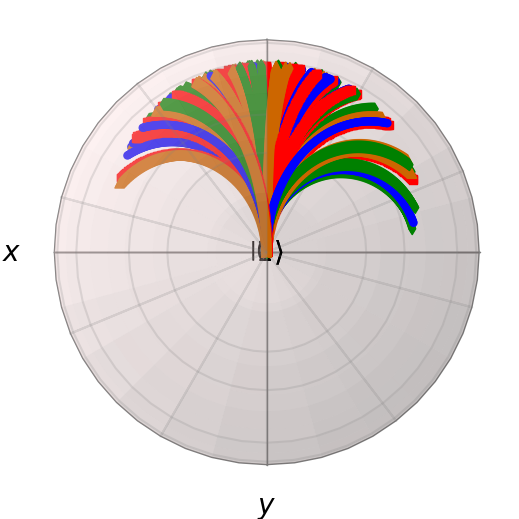

In [12]:
import numpy as np
from qutip import Bloch, about

import matplotlib.pyplot as plt

# Simulation parameters
n_atoms = 100  # Number of atoms in the ensemble
gamma = 1.0    # Inhomogeneous broadening width (std dev of detunings)
t_final = 1.0 # Final time for the evolution
n_steps = 201  # Number of time steps

# Create a distribution of detunings for the atoms
# Using a Gaussian distribution centered at 0
detunings = np.random.normal(0, gamma, n_atoms)

# Time array for the evolution
times = np.linspace(0, t_final, n_steps)

# Initialize the Bloch sphere for visualization
b = Bloch()
b.vector_color = [plt.cm.jet(i) for i in np.linspace(0, 1, n_atoms)]

# Set the initial state for all atoms to the ground state (|g> or south pole)
initial_state = np.array([0, 0, 1])
# Add the initial state vectors to the Bloch sphere
b.add_vectors([initial_state] * n_atoms)
# b.show()
# Calculate the final states for all atoms
final_vectors = []
for delta in detunings:
    omega_x = 1.0
    precession_axis = [omega_x, 0, -delta]
    
    # Calculate the path for each atom
    path_points = []
    for t in times:
        angle = np.sqrt(omega_x**2 + delta**2) * t
        # Use the internal rotation method from the Bloch sphere object
        # It takes (vector, angle, axis)
        # The _rotate_vec method is not part of the public API and may have been removed.
        # We can implement the rotation using Rodrigues' rotation formula directly.
        k = np.array(precession_axis) / np.linalg.norm(precession_axis)
        v = initial_state
        rotated_vector = v * np.cos(angle) + np.cross(k, v) * np.sin(angle) + k * np.dot(k, v) * (1 - np.cos(angle))
        path_points.append(rotated_vector)
    
    # Add the path for this atom to the Bloch sphere
    b.add_points(np.array(path_points).T)
    
    # Store the final vector
    final_vectors.append(path_points[-1])

# Add the final state vectors to the Bloch sphere
# b.add_vectors(final_vectors)
    # b.save()
# Set the view to look down from the north pole
b.view = [0, 90]
b.show()
# The animation is saved as 'bloch_anim.gif' in the current directory.
# You can display it in a notebook (if running in one) or open the file.
# print("Animation saved as bloch_anim.gif")

/opt/anaconda3/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


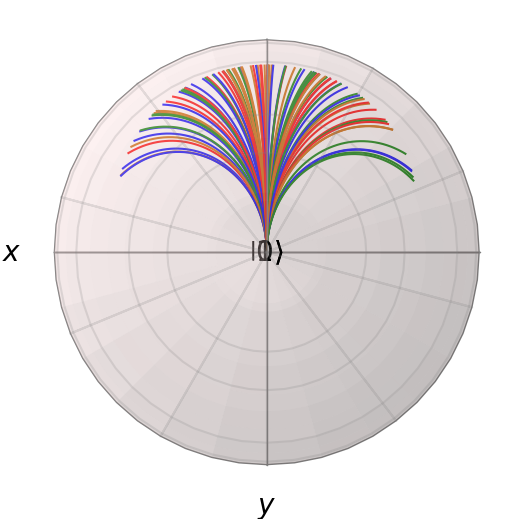

In [17]:
import numpy as np
from qutip import Bloch, about
from qutip import sigmax, sigmaz, mesolve, basis
from qutip import sigmay

import matplotlib.pyplot as plt

# Simulation parameters
n_atoms = 100  # Number of atoms in the ensemble
gamma = 1.0    # Inhomogeneous broadening width (std dev of detunings)
t_final = 1.0 # Final time for the evolution
n_steps = 201  # Number of time steps

# Create a distribution of detunings for the atoms
# Using a Gaussian distribution centered at 0
detunings = np.random.normal(0, gamma, n_atoms)

# Time array for the evolution
times = np.linspace(0, t_final, n_steps)

# Initialize the Bloch sphere for visualization
b = Bloch()
b.vector_color = [plt.cm.jet(i) for i in np.linspace(0, 1, n_atoms)]

# Set the initial state for all atoms to the ground state (|g> or south pole)
initial_state = np.array([0, 0, 1])
# Add the initial state vectors to the Bloch sphere
b.add_vectors([initial_state] * n_atoms)
# b.show()
# Calculate the final states for all atoms
final_vectors = []
for delta in detunings:
    # Define the Hamiltonian for a two-level system
    # H = - (delta/2) * sigma_z + (omega_x/2) * sigma_x
    # In QuTiP, we can use sigmax() and sigmaz()
    
    omega_x = 1.0
    H = (omega_x / 2) * sigmax() - (delta / 2) * sigmaz()
    
    # Initial state is the ground state |g>, which corresponds to |0> in the computational basis
    # or the north pole of the Bloch sphere.
    psi0 = basis(2, 0)
    
    # Solve the master equation for the evolution
    # Since there's no dissipation, this is equivalent to solving the Schrödinger equation.
    result = mesolve(H, psi0, times, [], [])
    
    # Extract the expectation values for sigma_x, sigma_y, sigma_z to get the Bloch vector components
    # The e_ops argument in mesolve is used to specify operators for which to calculate expectation values.
    # We need to provide sigmax(), sigmay(), and sigmaz() to get the Bloch vector components.
    result = mesolve(H, psi0, times, [], [sigmax(), sigmay(), sigmaz()])
    pnts = np.array(result.expect)
    
    # Add the path for this atom to the Bloch sphere
    b.add_points(pnts, meth='l')
    
    # Store the final vector
    final_vectors.append(pnts[:, -1])

# Add the final state vectors to the Bloch sphere
# b.add_vectors(final_vectors)
    # b.save()
# Set the view to look down from the north pole
b.view = [0, 90]
b.show()
# The animation is saved as 'bloch_anim.gif' in the current directory.
# You can display it in a notebook (if running in one) or open the file.
# print("Animation saved as bloch_anim.gif")

/opt/anaconda3/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


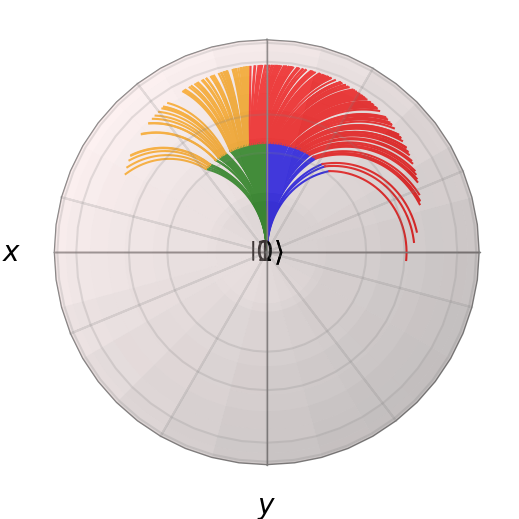

<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
from qutip import Bloch, about
from qutip import sigmax, sigmaz, mesolve, basis
from qutip import sigmay

import matplotlib.pyplot as plt

# Simulation parameters
n_atoms = 201  # Number of atoms in the ensemble
gamma = 1.0    # Inhomogeneous broadening width (std dev of detunings)
t_final = 0.5 # Final time for the evolution
n_steps = 201  # Number of time steps

# Create a distribution of detunings for the atoms
# Using a Gaussian distribution centered at 0
detunings = np.random.normal(0, gamma, n_atoms)

# Time array for the evolution
times = np.linspace(0, t_final, n_steps)

plt.figure()
# Initialize the Bloch sphere for visualization
b = Bloch()
b.vector_color = [plt.cm.jet(i) for i in np.linspace(0, 1, n_atoms)]

# Set the initial state for all atoms to the ground state (|g> or south pole)
initial_state = np.array([0, 0, 1])
# Add the initial state vectors to the Bloch sphere
b.add_vectors([initial_state] * n_atoms)
# b.show()
# Calculate the final states for all atoms
final_vectors = []
for delta in detunings:
    # Define the Hamiltonian for a two-level system
    # H = - (delta/2) * sigma_z + (omega_x/2) * sigma_x
    # In QuTiP, we can use sigmax() and sigmaz()
    
    omega_x = 1.0
    H = (omega_x / 2) * sigmax() - (delta / 2) * sigmaz()
    
    # Initial state is the ground state |g>, which corresponds to |0> in the computational basis
    # or the north pole of the Bloch sphere.
    psi0 = basis(2, 0)
    

    # Second pulse with a detuning
    # The final state of the first pulse is the initial state for the second
    # To get the final state, we need to solve for it.
    # We can get both expectation values and states in one call.
    result = mesolve(H, psi0, times, [], [sigmax(), sigmay(), sigmaz()], options={'store_states': True})
    pnts = np.array(result.expect)
    
    # Add the path for this atom to the Bloch sphere
    if delta >0:
        b.add_points(pnts, meth='l', colors=['blue'])
    else: b.add_points(pnts, meth='l', colors=['green'])
    
    # Store the final vector and state
    final_vectors.append(pnts[:, -1])
    psi1 = result.states[-1]

    # Define the Hamiltonian for the second pulse with a detuning offset
    detuning_offset = 2*np.pi*0.1  # Detuning for the second pulse
    H2 = (omega_x / 2) * sigmax() - ((delta + detuning_offset) / 2) * sigmaz()

    # Evolve for the second pulse
    result2 = mesolve(H2, psi1, times, [], [sigmax(), sigmay(), sigmaz()])
    pnts2 = np.array(result2.expect)

    # Add the path for the second pulse to the Bloch sphere
    if delta+detuning_offset > 0:
        b.add_points(pnts2, meth='l', colors=['red'])
    else: b.add_points(pnts2, meth='l', colors=['orange'])

    # Overwrite the final vector with the one from the second pulse
    final_vectors[-1] = pnts2[:, -1]

# Add the final state vectors to the Bloch sphere
# b.add_vectors(final_vectors)
    # b.save()
# Set the view to look down from the north pole
b.view = [0, 90]
b.save('Ensemble_Bloch.pdf')
b.show()
# The animation is saved as 'bloch_anim.gif' in the current directory.
# You can display it in a notebook (if running in one) or open the file.
# print("Animation saved as bloch_anim.gif")

/opt/anaconda3/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


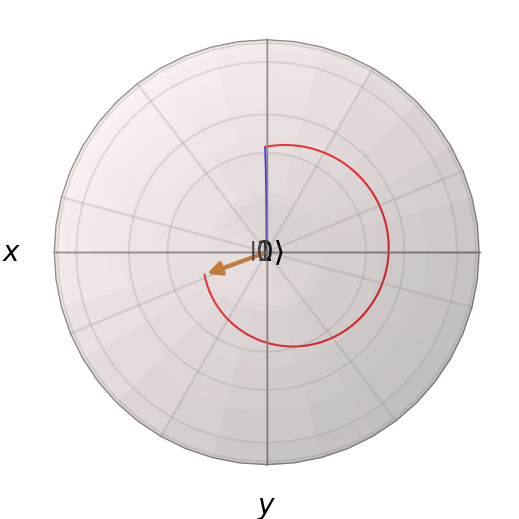

In [ ]:
import numpy as np
from qutip import Bloch, about
from qutip import sigmax, sigmaz, mesolve, basis
from qutip import sigmay

import matplotlib.pyplot as plt

# Simulation parameters
n_atoms = 101  # Number of atoms in the ensemble
gamma = 1.0    # Inhomogeneous broadening width (std dev of detunings)
t_final = 0.5 # Final time for the evolution
n_steps = 201  # Number of time steps

# Create a distribution of detunings for the atoms
# Using a Gaussian distribution centered at 0
detunings = np.random.normal(0, gamma, n_atoms)

# Time array for the evolution
times = np.linspace(0, t_final, n_steps)

# Initialize the Bloch sphere for visualization
b = Bloch()
b.vector_color = [plt.cm.jet(i) for i in np.linspace(0, 1, n_atoms)]

# Set the initial state for all atoms to the ground state (|g> or south pole)
initial_state = np.array([0, 0, 1])
# Add the initial state vectors to the Bloch sphere
b.add_vectors([initial_state] * n_atoms)

# Store all points for all atoms
all_pnts1 = []
all_pnts2 = []

for delta in detunings:
    # Define the Hamiltonian for a two-level system
    omega_x = 1.0
    H = (omega_x / 2) * sigmax() - (delta / 2) * sigmaz()
    
    # Initial state is the ground state |g>
    psi0 = basis(2, 0)
    
    # First pulse
    result = mesolve(H, psi0, times, [], [sigmax(), sigmay(), sigmaz()], options={'store_states': True})
    pnts = np.array(result.expect)
    all_pnts1.append(pnts)
    
    psi1 = result.states[-1]

    # Define the Hamiltonian for the second pulse with a detuning offset
    detuning_offset = 2*np.pi*1.5  # Detuning for the second pulse
    H2 = (omega_x / 2) * sigmax() - ((delta + detuning_offset) / 2) * sigmaz()

    # Evolve for the second pulse
    result2 = mesolve(H2, psi1, times, [], [sigmax(), sigmay(), sigmaz()])
    pnts2 = np.array(result2.expect)
    all_pnts2.append(pnts2)

# Calculate the average trajectory for each pulse
avg_pnts1 = np.mean(all_pnts1, axis=0)
avg_pnts2 = np.mean(all_pnts2, axis=0)

# Add the average trajectories to the Bloch sphere
b.add_points(avg_pnts1, meth='l')
b.add_points(avg_pnts2, meth='l')

# Calculate and add the final average vector
final_vectors = [p[-1] for p in all_pnts2]
avg_final_vector = np.mean(final_vectors, axis=0)
avg_final_vector = np.mean([p[:, -1] for p in all_pnts2], axis=0)
b.add_vectors([avg_final_vector])

# Set the view to look down from the north pole
b.view = [0, 90]
b.save('Ensemble_Bloch_Average_3pi.pdf')
b.show()


/opt/anaconda3/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


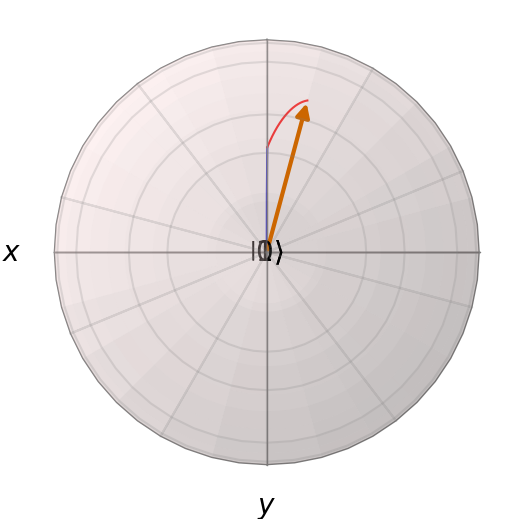

In [30]:
import numpy as np
from qutip import Bloch, about
from qutip import sigmax, sigmaz, mesolve, basis
from qutip import sigmay

import matplotlib.pyplot as plt

# Simulation parameters
n_atoms = 101  # Number of atoms in the ensemble
gamma = 1.0    # Inhomogeneous broadening width (std dev of detunings)
t_final = 0.5 # Final time for the evolution
n_steps = 201  # Number of time steps

# Create a distribution of detunings for the atoms
# Using a Gaussian distribution centered at 0
detunings = np.random.normal(0, gamma, n_atoms)

# Time array for the evolution
times = np.linspace(0, t_final, n_steps)

# Initialize the Bloch sphere for visualization
b = Bloch()
b.vector_color = [plt.cm.jet(i) for i in np.linspace(0, 1, n_atoms)]

# Set the initial state for all atoms to the ground state (|g> or south pole)
initial_state = np.array([0, 0, 1])
# Add the initial state vectors to the Bloch sphere
b.add_vectors([initial_state] * n_atoms)

# Store all points for all atoms
all_pnts1 = []
all_pnts2 = []

for delta in detunings:
    # Define the Hamiltonian for a two-level system
    omega_x = 1.0
    H = (omega_x / 2) * sigmax() - (delta / 2) * sigmaz()
    
    # Initial state is the ground state |g>
    psi0 = basis(2, 0)
    
    # First pulse
    result = mesolve(H, psi0, times, [], [sigmax(), sigmay(), sigmaz()], options={'store_states': True})
    pnts = np.array(result.expect)
    all_pnts1.append(pnts)
    
    psi1 = result.states[-1]

    # Define the Hamiltonian for the second pulse with a detuning offset
    detuning_offset = 2*np.pi*0.1  # Detuning for the second pulse
    H2 = (omega_x / 2) * sigmax() - ((delta + detuning_offset) / 2) * sigmaz()

    # Evolve for the second pulse
    result2 = mesolve(H2, psi1, times, [], [sigmax(), sigmay(), sigmaz()])
    pnts2 = np.array(result2.expect)
    all_pnts2.append(pnts2)

# Calculate the average trajectory for each pulse
avg_pnts1 = np.mean(all_pnts1, axis=0)
avg_pnts2 = np.mean(all_pnts2, axis=0)

# Add the average trajectories to the Bloch sphere
b.add_points(avg_pnts1, meth='l')
b.add_points(avg_pnts2, meth='l')

# Calculate and add the final average vector
final_vectors = [p[-1] for p in all_pnts2]
avg_final_vector = np.mean(final_vectors, axis=0)
avg_final_vector = np.mean([p[:, -1] for p in all_pnts2], axis=0)
b.add_vectors([avg_final_vector])

# Set the view to look down from the north pole
b.view = [0, 90]
b.save('Ensemble_Bloch_Average_1_10th_pi.pdf')
b.show()


/opt/anaconda3/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


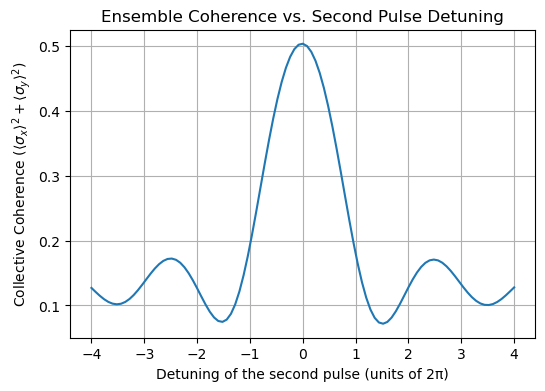

In [36]:
# Define a range of detunings for the second pulse
detuning_offsets = np.linspace(-2 * np.pi * 4, 2 * np.pi * 4, 101)
coherences = []

# Loop over the detuning offsets
for detuning_offset in detuning_offsets:
    final_vectors_for_offset = []
    for delta in detunings:
        # First pulse Hamiltonian
        omega_x = 1.0
        H = (omega_x / 2) * sigmax() - (delta / 2) * sigmaz()
        
        # Initial state
        psi0 = basis(2, 0)
        
        # Evolve for the first pulse
        result = mesolve(H, psi0, times, [], [], options={'store_states': True})
        psi1 = result.states[-1]

        # Second pulse Hamiltonian
        H2 = (omega_x / 2) * sigmax() - ((delta + detuning_offset) / 2) * sigmaz()

        # Evolve for the second pulse
        result2 = mesolve(H2, psi1, times, [], [sigmax(), sigmay(), sigmaz()])
        
        # Store the final Bloch vector
        final_vectors_for_offset.append(result2.expect[0][-1] + 1j * result2.expect[1][-1])

    # Calculate the average coherence
    avg_coherence = np.mean(final_vectors_for_offset)
    
    # Calculate sx^2 + sy^2
    sx = np.real(avg_coherence)
    sy = np.imag(avg_coherence)
    coherences.append(sx**2 + sy**2)

# Plot the results
plt.figure(figsize=(6, 4))
plt.plot(detuning_offsets / (2 * np.pi), coherences)
plt.xlabel("Detuning of the second pulse (units of 2π)")
plt.ylabel(r"Collective Coherence ($\langle \sigma_x \rangle^2 + \langle \sigma_y \rangle^2$)")
plt.title("Ensemble Coherence vs. Second Pulse Detuning")
plt.grid(True)
plt.savefig('Ensemble_Coherence_vs_Detuning.pdf')
plt.show()